# 2. Check the stage-by-stage simulator

This notebook checks the numerical race predictions from the Volterra accuracy notebook against two forward simulations. The stage-exact sampler draws what happens within each stage without a time grid, while `cssm.race_multistage`, introduced by the original forward-race work, uses Euler steps and can miss a boundary crossing between checks. Comparing both simulators with the same analytic and numerical references separates Monte Carlo variation from Euler time-discretization bias.

In [1]:
from pathlib import Path
import os
import sys
import tempfile
from time import perf_counter

root = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "setup.py").exists() and (p / "ssms").exists())
folder = root / "notebooks/stage_simulation"
sys.path[:0] = [str(root / "notebooks"), str(root)]
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "race-notebook-mpl"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cssm
from IPython.display import display
from volterra_accuracy.experiment_helpers import (
    analytic_cases, build_model, parameter_table, exact_marginals,
    probability_bins, specifications,
    compare_sample, empirical_cdf, refine_reference, save_results,
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", 12)
plt.rcParams.update({"figure.figsize": (10, 3.8), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})


In [2]:
N_TRIALS = 100_000
N_REPEATS = 3
SEEDS = [20261101, 20261102, 20261103]
SHORT_MIDDLE_SEEDS = [20261120, 20261121, 20261122]
DT_VALUES = [1e-3, 5e-4, 2.5e-4]
RUNNER_RELATIVE_DRIFTS = [.67, 0, -.18]
RUNNER_SEED_BASE = 20261020

print(f"Final setting: {N_TRIALS:,} trials per run; "
      f"{N_REPEATS} independent stage-sampler runs for each changing-parameter case.")


def record_run(rt, choices, *, case, method, detail_method, dt, repeat,
               seed, elapsed, edges, bins, omission, extra_fields=None):
    row, detail = compare_sample(rt, choices, edges, bins, omission)
    row["reference_omission"] = row.pop("predicted_omission")
    row["flagged_categories"] = row.pop("rejected_categories")
    row.update(case=case, method=method, dt=dt, repeat=repeat,
               seed=seed, simulation_time_seconds=elapsed)
    if extra_fields:
        row.update(extra_fields)
    detail = detail.assign(case=case, method=detail_method, seed=seed)
    return row, detail


def production_simulator_inputs(specs):
    n_runners = len(specs)
    max_stages = max(len(spec["mu"]) for spec in specs)
    shape = (1, n_runners, max_stages)
    mu = np.zeros(shape)
    sigma = np.ones(shape)
    nodes = np.zeros(shape)
    intercept = np.zeros(shape)
    slope = np.zeros(shape)
    stages = np.zeros((1, n_runners), dtype=np.int32)
    x0 = np.zeros((1, n_runners))

    for runner, spec in enumerate(specs):
        breaks = np.asarray(spec["breaks"], dtype=float)
        slopes = np.asarray(spec["boundary_slopes"], dtype=float)
        n_stages = len(slopes)
        boundary_starts = spec["boundary0"] + np.r_[
            0.0, np.cumsum(slopes[:-1] * np.diff(breaks)[:-1])
        ]
        mu[0, runner, :n_stages] = spec["mu"]
        sigma[0, runner, :n_stages] = spec["sigma"]
        nodes[0, runner, :n_stages] = breaks[:-1]
        intercept[0, runner, :n_stages] = boundary_starts
        slope[0, runner, :n_stages] = slopes
        stages[0, runner] = n_stages
        x0[0, runner] = spec.get("x0", 0.0)

    return {
        "mu_array": mu,
        "sigma_array": sigma,
        "node_array": nodes,
        "d_array": stages,
        "upper_intercept_array": intercept,
        "upper_slope_array": slope,
        "x0_array": x0,
    }


def simulate_production_euler(specs, n_trials, dt, seed):
    deadline = float(specs[0]["breaks"][-1])
    out = cssm.race_multistage(
        **production_simulator_inputs(specs),
        n_samples=n_trials,
        delta_t=dt,
        max_t=deadline,
        deadline=deadline,
        return_option="minimal",
        random_state=seed,
    )
    rt = out["rts"][:, 0, 0].astype(float)
    choices = out["choices"][:, 0, 0].astype(int)
    omissions = rt == -999.0
    rt[omissions] = deadline
    choices[omissions] = -1
    return rt, choices


Final setting: 100,000 trials per run; 3 independent stage-sampler runs for each changing-parameter case.


### Stage-by-stage sampler

Within stage $k$, the accumulator and its upper boundary are

$$
dX(t)=\mu_k\,dt+\sigma_k\,dW(t),
\qquad
a(t)=a_k+b_k t.
$$

At the beginning of the stage, let

$$
d=a(t_k)-X(t_k)>0,
\qquad
v=\mu_k-b_k,
\qquad
D=t_{k+1}-t_k.
$$

Here, $d$ is the distance to the boundary, $v$ is the drift relative to the moving boundary, and $D$ is the stage duration. The sampler draws the first-passage time $\tau$ directly rather than stepping through time.

For $v\neq0$, conditional on an eventual hit,

$$
\tau\sim\operatorname{Wald}\!\left(\frac{d}{|v|},\frac{d^2}{\sigma_k^2}\right).
$$

When $v>0$, the boundary is eventually reached with probability one. When $v<0$, the probability of ever reaching it is

$$
P(\tau<\infty)=\exp\!\left(\frac{2vd}{\sigma_k^2}\right).
$$

For zero relative drift,

$$
\tau=\frac{d^2}{\sigma_k^2 Z^2},
\qquad Z\sim N(0,1).
$$

If $\tau\le D$, the crossing time is recorded as $t_k+\tau$. Otherwise, the trial survives the stage and needs a position at $t_{k+1}$. A proposal is drawn from the unrestricted transition,

$$
Y\sim N\!\left(X(t_k)+\mu_kD,\;\sigma_k^2D\right),
$$

and accepted with probability

$$
1-\exp\!\left[-\frac{2d\{a(t_{k+1})-Y\}}{\sigma_k^2D}\right]
$$

when $Y<a(t_{k+1})$. This rejection step samples the endpoint conditional on having stayed below the boundary throughout the stage. The accepted endpoint becomes the starting position for the next stage. `total_proposals` counts all endpoint proposals, including rejected ones.

For a race, this procedure is applied to every accumulator. If $\tau_i$ is runner $i$'s crossing time, then

$$
RT=\min_i\tau_i,
\qquad
\text{choice}=\operatorname*{arg\,min}_i\tau_i.
$$

A trial is recorded as an omission when no runner crosses before the common deadline.


In [3]:
def sample_runner(acc, n, rng):
    hits = np.full(n, np.inf)
    positions = np.full(n, acc.x0, dtype=float)
    active = np.arange(n)
    total_proposals = 0

    for stage, duration in enumerate(np.diff(acc.breaks)):
        if not active.size:
            break

        x = positions[active].copy()
        gap = acc._boundary_starts[stage] - x
        sigma = acc.sigma[stage]
        relative_drift = acc.mu[stage] - acc.boundary_slopes[stage]

        if relative_drift == 0:
            tau = (gap / (sigma * rng.standard_normal(active.size))) ** 2
        else:
            tau = rng.wald(gap / abs(relative_drift), (gap / sigma) ** 2)
            if relative_drift < 0:
                hit_probability = np.exp(2 * relative_drift * gap / sigma**2)
                tau[rng.random(active.size) >= hit_probability] = np.inf

        crossed = tau <= duration
        hits[active[crossed]] = acc.breaks[stage] + tau[crossed]
        active = active[~crossed]

        if stage == acc.n_stages - 1:
            break

        x, gap = x[~crossed], gap[~crossed]
        pending = np.arange(active.size)
        boundary_end = acc.boundary(acc.breaks[stage + 1])

        for _ in range(10_000):
            if not pending.size:
                break

            total_proposals += pending.size
            candidate = rng.normal(
                x[pending] + acc.mu[stage] * duration,
                sigma * np.sqrt(duration),
            )
            end_gap = np.maximum(boundary_end - candidate, 0.0)
            acceptance = -np.expm1(
                -2 * gap[pending] * end_gap / (sigma**2 * duration)
            )
            accepted = rng.random(pending.size) < acceptance
            positions[active[pending[accepted]]] = candidate[accepted]
            pending = pending[~accepted]
        else:
            raise RuntimeError("Survivor rejection exceeded 10000 rounds")

    return hits, total_proposals


def sample_race(model, n, seed):
    rng = np.random.default_rng(seed)
    results = [sample_runner(accumulator, n, rng)
               for accumulator in model.accumulators]
    hits = np.stack([result[0] for result in results])
    rt = hits.min(axis=0)
    choices = hits.argmin(axis=0)
    omissions = ~np.isfinite(rt)
    choices[omissions] = -1
    rt[omissions] = model.deadline
    total_proposals = sum(result[1] for result in results)
    return rt, choices, total_proposals


### First, check one runner

We test positive, zero, and negative relative drift across five stages. The DKW bound measures the largest CDF difference over the whole time range. After adjusting for the three drift cases, it gives 95% confidence that all three simulated CDFs are within the reported bound of their exact CDFs.

In [4]:
runner_rows = []
for offset, relative_drift in enumerate(RUNNER_RELATIVE_DRIFTS):
    spec = dict(breaks=[0, .02, .57, .95, 1.42, 2],
                mu=[relative_drift-.12]*5, sigma=[.8]*5,
                boundary_slopes=[-.12]*5, boundary0=1.45, x0=.1)
    runner = build_model([spec, spec]).accumulators[0]
    seed = RUNNER_SEED_BASE + offset
    hits, total_proposals = sample_runner(runner, N_TRIALS, np.random.default_rng(seed))

    grid = np.linspace(0, 2, 2001)
    exact_cdf = exact_marginals([spec], grid)[1][:, 0]
    observed_cdf = np.searchsorted(np.sort(hits), grid, side="right") / N_TRIALS
    bound = np.sqrt(np.log(2*3/.05) / (2*N_TRIALS))
    difference = float(abs(observed_cdf-exact_cdf).max())
    runner_rows.append(dict(relative_drift=relative_drift, max_cdf_discrepancy=difference,
                            simultaneous_95_bound=bound, within_bound=difference <= bound,
                            total_proposals=total_proposals, seed=seed))
runner_checks = pd.DataFrame(runner_rows)
display(runner_checks)


,relative_drift,max_cdf_discrepancy,simultaneous_95_bound,within_bound,total_proposals,seed
0,0.67,0.001486,0.004893,True,364260,20261020
1,0.00,0.001060,0.004893,True,389108,20261021
2,-0.18,0.001671,0.004893,True,393247,20261022


### Then, check the race

The first case, called the **Analytic race** in the code and tables, is a two-runner, constant-parameter race with a deadline of 2. Runner 0 starts at 0.10 below a boundary of 1.45, with drift 0.55, noise 0.80, and boundary slope −0.12. Runner 1 starts at −0.05 below a boundary of 1.30, with drift 0.30, noise 0.95, and boundary slope 0.06. Both runners therefore begin 1.35 units below their boundaries.

Each runner is represented using five stages, but its parameters stay constant across all five; the breakpoints are artificial subdivisions used to test stage propagation. The process is consequently equivalent to a single constant-coefficient diffusion against a linear boundary, whose first-passage time has a known Wald distribution. Combining the two runners’ analytic densities and survival probabilities gives the analytic race reference.

We then test a race where each runner’s drift, noise, and boundary slope genuinely change between stages. Finally, we test the same race with runner 0’s second stage shortened to $0.0001$ time units, from 0.18 to 0.1801.

In [5]:
CHANGING_CASE = "Runner settings vary by stage"
SHORT_MIDDLE_CASE = "Same race, middle stage only lasts 0.0001"
race_cases = {
    "Analytic race": analytic_cases()["5 stages"],
    CHANGING_CASE: specifications("B"),
    SHORT_MIDDLE_CASE: specifications("B"),
}
race_cases[SHORT_MIDDLE_CASE][0]["breaks"] = [0, .18, .1801, .87, 1.31, 1.8]

display(parameter_table(race_cases[CHANGING_CASE]))

references, reference_rows = {}, []
for case_name, case_specs in race_cases.items():
    deadlines = [float(spec["breaks"][-1]) for spec in case_specs]
    reference_deadline = deadlines[0]
    if not np.allclose(deadlines, reference_deadline):
        raise ValueError(f"{case_name}: runner deadlines must match; got {deadlines}")

    if case_name == "Analytic race":
        edges, bins, omission = probability_bins(case_specs)
        references[case_name] = (build_model(case_specs), edges, bins, omission)
    else:
        model, edges, bins, omission, checks = refine_reference(case_specs)
        references[case_name] = (model, edges, bins, omission)
        reference_rows.append(dict(case=case_name, **checks))

reference_checks = pd.DataFrame(reference_rows)
display(reference_checks)


,runner,stage,start,duration,mu,sigma,boundary_slope,initial_boundary,x0
0,0,1,0.00,0.18,0.20,0.75,-0.03,1.35,0.00
1,0,2,0.18,0.36,0.85,0.85,0.04,1.35,0.00
2,0,3,0.54,0.33,0.35,0.80,-0.08,1.35,0.00
3,0,4,0.87,0.44,0.70,0.90,0.02,1.35,0.00
4,0,5,1.31,0.49,0.25,0.75,-0.04,1.35,0.00
5,1,1,0.00,0.31,0.40,0.85,0.02,1.38,-0.05
6,1,2,0.31,0.32,0.15,0.75,-0.05,1.38,-0.05
7,1,3,0.63,0.43,0.90,0.95,0.03,1.38,-0.05
8,1,4,1.06,0.40,0.30,0.80,-0.07,1.38,-0.05
9,1,5,1.46,0.34,0.60,0.90,0.01,1.38,-0.05


,case,order_change,time_integration_change,omission_change,mass_error
0,Runner settings vary by stage,4.510281e-17,7.632783e-17,7.771561e-16,7.771561e-16
1,"Same race, middle stage only lasts 0.0001",1.026956e-15,6.938894e-17,7.771561e-16,6.661338e-16


**Categories flagged** counts how many outcome groups had observed counts unusually far from the model’s predictions. For each group, let $n=100{,}000$ be the races in the run, $p$ its predicted probability, and $k$ its observed count. We compare $k$ with a binomial count $X\sim\operatorname{Binomial}(n,p)$ and flag the group when its two-sided p-value is below $0.05/25=0.002$ (accounting for all 25 groups). Thus, a value of 1 means one group passed this cutoff; it does not mean one race was rejected.

In [6]:
run_rows, details, samples = [], [], {}
for case_index, name in enumerate(race_cases):
    model, edges, bins, omission = references[name]
    if name == CHANGING_CASE:
        seeds = SEEDS
    elif name == SHORT_MIDDLE_CASE:
        seeds = SHORT_MIDDLE_SEEDS
    else:
        seeds = [20261110 + case_index]

    for repeat, seed in enumerate(seeds):
        start = perf_counter()
        rt, choices, total_proposals = sample_race(model, N_TRIALS, seed)
        elapsed = perf_counter() - start
        row, detail = record_run(
            rt, choices, case=name, method="Stage sampler",
            detail_method="Stage sampler", dt=np.nan, repeat=repeat+1,
            seed=seed, elapsed=elapsed, edges=edges, bins=bins,
            omission=omission, extra_fields={"total_proposals": total_proposals},
        )
        run_rows.append(row)
        details.append(detail)
        if repeat == 0:
            samples[(name, "Stage sampler")] = (rt, choices)
    print("Completed stage simulation:", name)

model, edges, bins, omission = references[CHANGING_CASE]
for dt_index, dt in enumerate(DT_VALUES):
    for repeat in range(N_REPEATS):
        seed = 20261200 + 10*dt_index + repeat
        start = perf_counter()
        rt, choices = simulate_production_euler(
            race_cases[CHANGING_CASE], N_TRIALS, dt, seed
        )
        elapsed = perf_counter() - start
        row, detail = record_run(
            rt, choices, case=CHANGING_CASE, method="Production Euler",
            detail_method=f"Production Euler {dt:g}", dt=dt, repeat=repeat+1,
            seed=seed, elapsed=elapsed, edges=edges, bins=bins,
            omission=omission, extra_fields={"rejection_proposals": np.nan},
        )
        run_rows.append(row)
        details.append(detail)
        if repeat == 0:
            samples[(CHANGING_CASE, f"Production Euler {dt:g}")] = (rt, choices)
    print(f"Completed production Euler: dt={dt:g}")

runs = pd.DataFrame(run_rows)
category_checks = pd.concat(details, ignore_index=True)
display(runs[["case", "method", "dt", "seed", "observed_omission",
              "reference_omission", "flagged_categories", "simulation_time_seconds"]])


Completed stage simulation: Analytic race
Completed stage simulation: Runner settings vary by stage


Completed stage simulation: Same race, middle stage only lasts 0.0001


Completed production Euler: dt=0.001


Completed production Euler: dt=0.0005


Completed production Euler: dt=0.00025


,case,method,dt,seed,observed_omission,reference_omission,flagged_categories,simulation_time_seconds
0,Analytic race,Stage sampler,NaN,20261110,0.20179,0.200959,0,0.050147
1,Runner settings vary by stage,Stage sampler,NaN,20261101,0.25797,0.258292,0,0.049964
2,Runner settings vary by stage,Stage sampler,NaN,20261102,0.25806,0.258292,0,0.050587
3,Runner settings vary by stage,Stage sampler,NaN,20261103,0.26147,0.258292,0,0.050670
4,"Same race, middle stage only lasts 0.0001",Stage sampler,NaN,20261120,0.29074,0.291078,1,0.049007
5,"Same race, middle stage only lasts 0.0001",Stage sampler,NaN,20261121,0.29292,0.291078,1,0.050787
6,"Same race, middle stage only lasts 0.0001",Stage sampler,NaN,20261122,0.28932,0.291078,0,0.052752
7,Runner settings vary by stage,Production Euler,0.00100,20261200,0.26498,0.258292,4,2.221141
8,Runner settings vary by stage,Production Euler,0.00100,20261201,0.26625,0.258292,6,2.240368
9,Runner settings vary by stage,Production Euler,0.00100,20261202,0.26487,0.258292,2,2.210687


**Interpretation.** The stage sampler has no flagged categories for the Analytic race or the ordinary changing-parameter race; the short-stage case has two isolated flags across 75 category checks. The production Euler simulations produce repeated flags and a higher observed omission proportion than the reference predicts at every tested time step, which is consistent with persistent time-discretization bias.

### Compare response times and omissions

The response CDF includes every trial, even runners that do not cross before the deadline. That is why it can end below 1. The 95% Wilson intervals show sampling uncertainty for each run. We adjust the category tests across 24 choice/RT bins plus omissions.

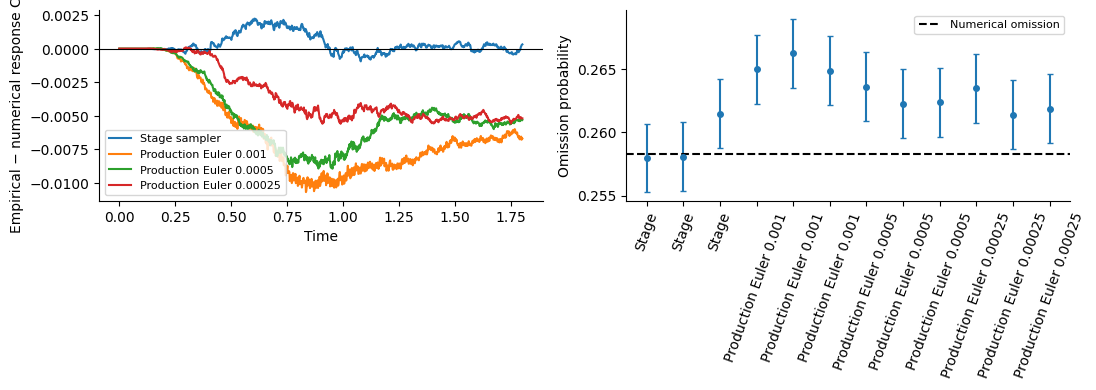

In [7]:
grid = np.linspace(0, 1.8, 1001)
model, edges, bins, omission = references[CHANGING_CASE]
reference_cdf = 1 - np.prod(1-model.marginals(grid)[1], axis=-1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for (case, label), (rt, choices) in samples.items():
    if case == CHANGING_CASE:
        axes[0].plot(grid, empirical_cdf(rt, choices, grid)-reference_cdf, label=label)
axes[0].axhline(0, color="black", lw=.8)
axes[0].set(xlabel="Time", ylabel="Empirical − numerical response CDF")
axes[0].legend(fontsize=8)

varying_settings_runs = runs[runs["case"] == CHANGING_CASE].reset_index(drop=True)
labels = ["Stage" if row.method == "Stage sampler" else f"Production Euler {row.dt:g}"
          for row in varying_settings_runs.itertuples()]
axes[1].errorbar(
    np.arange(len(varying_settings_runs)), varying_settings_runs.observed_omission,
    yerr=[varying_settings_runs.observed_omission-varying_settings_runs.omission_lower,
          varying_settings_runs.omission_upper-varying_settings_runs.observed_omission],
    fmt="o", ms=4, capsize=2,
)
axes[1].axhline(omission, color="black", ls="--", label="Numerical omission")
axes[1].set(xticks=np.arange(len(labels)), xticklabels=labels, ylabel="Omission probability")
axes[1].tick_params(axis="x", labelrotation=70)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


**Interpretation.** The stage sampler’s response CDF stays close to the numerical reference, while the production Euler curves fall below it over much of the time range. In this example, reducing the Euler step size does not produce a clear monotonic improvement across runs.

In [8]:
timing = runs[runs["case"] == CHANGING_CASE].groupby(["method", "dt"], dropna=False).agg(
    median_seconds=("simulation_time_seconds", "median"),
    min_seconds=("simulation_time_seconds", "min"),
    max_seconds=("simulation_time_seconds", "max"),
    mean_omission=("observed_omission", "mean"),
    omission_sd=("observed_omission", "std"),
).reset_index()
stage_seconds = timing.loc[timing.method == "Stage sampler", "median_seconds"].iloc[0]
timing["time_relative_to_stage_sampler"] = timing.median_seconds / stage_seconds
timing.loc[len(timing)] = {
    "method": "Numerical reference",
    "dt": np.nan,
    "median_seconds": np.nan,
    "min_seconds": np.nan,
    "max_seconds": np.nan,
    "mean_omission": references[CHANGING_CASE][3],
    "omission_sd": np.nan,
    "time_relative_to_stage_sampler": np.nan,
}
display(timing)

assert runner_checks.within_bound.all()
save_results("02_simulation", {
    "single_runner_checks": runner_checks,
    "reference_refinement": reference_checks,
    "runs": runs,
    "category_checks": category_checks,
    "timing": timing,
    "varying_settings_parameters": parameter_table(race_cases[CHANGING_CASE]),
}, {
    "trials_per_run": N_TRIALS,
    "varying_settings_seeds": SEEDS,
    "short_middle_seeds": SHORT_MIDDLE_SEEDS,
    "euler_dt": DT_VALUES,
    "timing_repetitions": N_REPEATS,
    "seed_details": "runs.csv and single_runner_checks.csv",
    "inference": "Bonferroni within each run; single-run Wilson omission intervals",
})


,method,dt,median_seconds,min_seconds,max_seconds,mean_omission,omission_sd,time_relative_to_stage_sampler
0,Production Euler,0.00025,8.997761,8.942387,9.139159,0.262250,0.001093,177.867655
1,Production Euler,0.00050,4.597728,4.439526,4.689479,0.262737,0.000742,90.887844
2,Production Euler,0.00100,2.221141,2.210687,2.240368,0.265367,0.000767,43.907499
3,Stage sampler,NaN,0.050587,0.049964,0.050670,0.259167,0.001995,1.000000
4,Numerical reference,NaN,NaN,NaN,NaN,0.258292,NaN,NaN


PosixPath('/Users/mayan/HSSM/ssm-simulators/notebooks/volterra_accuracy/results/02_simulation')

**Interpretation.** For this changing-parameter race, the stage sampler is faster than the production Euler simulator across the tested time steps. Its mean omission estimate is also closer to the numerical reference, while the production Euler estimates retain a bias that does not decrease consistently across these runs.